# Handle Data Inconsistencies

This notebook handles:
1. Age inconsistent data points where `years_with_startup > founder_age` (train only - no rows removed from test)
2. Drops the `years_since_founding` column from both datasets
3. Analyzes and handles missing values appropriately for both datasets

**Output files:**
- `dataset/train_dropped_column.csv`
- `dataset/test_dropped_column.csv`


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Load both datasets
print("="*70)
print("LOADING DATASETS")
print("="*70)

print("\nLoading training data...")
train_df = pd.read_csv('dataset/train.csv')

print("Loading test data...")
test_df = pd.read_csv('dataset/test.csv')

# Store original dimensions
train_original_row_count = len(train_df)
train_original_col_count = len(train_df.columns)
test_original_row_count = len(test_df)
test_original_col_count = len(test_df.columns)

print(f"\nInitial training dataset shape: {train_df.shape}")
print(f"Initial test dataset shape: {test_df.shape}")
print(f"\nTraining columns: {list(train_df.columns)}")
print(f"\nTest columns: {list(test_df.columns)}")


LOADING DATASETS

Loading training data...
Loading test data...

Initial training dataset shape: (59611, 24)
Initial test dataset shape: (14900, 23)

Training columns: ['founder_id', 'founder_age', 'founder_gender', 'years_with_startup', 'founder_role', 'monthly_revenue_generated', 'work_life_balance_rating', 'venture_satisfaction', 'startup_performance_rating', 'funding_rounds_led', 'working_overtime', 'distance_from_investor_hub', 'education_background', 'personal_status', 'num_dependents', 'startup_stage', 'team_size_category', 'years_since_founding', 'remote_operations', 'leadership_scope', 'innovation_support', 'startup_reputation', 'founder_visibility', 'retention_status']

Test columns: ['founder_id', 'founder_age', 'founder_gender', 'years_with_startup', 'founder_role', 'monthly_revenue_generated', 'work_life_balance_rating', 'venture_satisfaction', 'startup_performance_rating', 'funding_rounds_led', 'working_overtime', 'distance_from_investor_hub', 'education_background', 'per

## Step 1: Handle Age Inconsistencies for Training Data

**Note:** We only remove rows from the training dataset. Test dataset rows are kept intact.


In [2]:
# Check for age inconsistencies where years_with_startup > founder_age
print("="*70)
print("STEP 1: HANDLING AGE INCONSISTENCIES (TRAINING DATA ONLY)")
print("="*70)

# Check for inconsistencies in training data
invalid_years_mask = train_df['years_with_startup'] > train_df['founder_age']
invalid_years_rows = train_df[invalid_years_mask]
num_rows_removed = len(invalid_years_rows)

print(f"\nFound {num_rows_removed} rows in TRAINING data where years_with_startup > founder_age:")
if num_rows_removed > 0:
    print(invalid_years_rows[['founder_id', 'founder_age', 'years_with_startup', 'years_since_founding']].to_string())

# Remove these inconsistent rows from training data only
print(f"\nRemoving {num_rows_removed} inconsistent rows from training data...")
train_df = train_df[~invalid_years_mask].copy()

print(f"Training dataset shape after removing inconsistent age rows: {train_df.shape}")
print(f"Rows removed from training: {num_rows_removed}")

# Check test data for information only (but don't remove rows)
print("\n" + "="*70)
print("CHECKING TEST DATA (NO ROWS WILL BE REMOVED)")
print("="*70)
test_invalid_years_mask = test_df['years_with_startup'] > test_df['founder_age']
test_invalid_count = test_invalid_years_mask.sum()
print(f"Found {test_invalid_count} rows in TEST data with age inconsistencies (these will be kept)")
if test_invalid_count > 0:
    print(test_df[test_invalid_years_mask][['founder_id', 'founder_age', 'years_with_startup', 'years_since_founding']].head(10).to_string())


STEP 1: HANDLING AGE INCONSISTENCIES (TRAINING DATA ONLY)

Found 3 rows in TRAINING data where years_with_startup > founder_age:
       founder_id  founder_age  years_with_startup  years_since_founding
50279       50946           13                  22                  63.0
51116        4762            6                   9                  65.0
56103       34398           23                  26                  42.0

Removing 3 inconsistent rows from training data...
Training dataset shape after removing inconsistent age rows: (59608, 24)
Rows removed from training: 3

CHECKING TEST DATA (NO ROWS WILL BE REMOVED)
Found 0 rows in TEST data with age inconsistencies (these will be kept)


## Step 2: Drop the years_since_founding Column (Both Datasets)


In [3]:
# Drop the years_since_founding column from both datasets
print("="*70)
print("STEP 2: DROPPING years_since_founding COLUMN")
print("="*70)

# Drop from training data
if 'years_since_founding' in train_df.columns:
    print(f"\nDropping column 'years_since_founding' from training data...")
    train_df = train_df.drop(columns=['years_since_founding'])
    print(f"✓ Column dropped from training data!")
else:
    print(f"\n⚠ Column 'years_since_founding' not found in training dataset.")

# Drop from test data
if 'years_since_founding' in test_df.columns:
    print(f"\nDropping column 'years_since_founding' from test data...")
    test_df = test_df.drop(columns=['years_since_founding'])
    print(f"✓ Column dropped from test data!")
else:
    print(f"\n⚠ Column 'years_since_founding' not found in test dataset.")

print(f"\nTraining dataset shape: {train_df.shape}")
print(f"Test dataset shape: {test_df.shape}")
print(f"\nTraining columns: {len(train_df.columns)}")
print(f"Test columns: {len(test_df.columns)}")


STEP 2: DROPPING years_since_founding COLUMN

Dropping column 'years_since_founding' from training data...
✓ Column dropped from training data!

Dropping column 'years_since_founding' from test data...
✓ Column dropped from test data!

Training dataset shape: (59608, 23)
Test dataset shape: (14900, 22)

Training columns: 23
Test columns: 22


## Step 3: Analyze Missing Values (Both Datasets)


In [4]:
# Analyze missing values in both datasets
print("="*70)
print("STEP 3: ANALYZING MISSING VALUES")
print("="*70)

# Training data missing values
print("\n" + "-"*70)
print("TRAINING DATA MISSING VALUES")
print("-"*70)

train_missing_summary = train_df.isnull().sum()
train_missing_summary = train_missing_summary[train_missing_summary > 0].sort_values(ascending=False)

print(f"\nMissing values per column:")
print(train_missing_summary)

print(f"\nPercentage of missing values per column:")
train_missing_percentage = (train_missing_summary / len(train_df) * 100).round(2)
for col, count in train_missing_summary.items():
    pct = train_missing_percentage[col]
    print(f"  {col}: {count} ({pct}%)")

# Test data missing values
print("\n" + "-"*70)
print("TEST DATA MISSING VALUES")
print("-"*70)

test_missing_summary = test_df.isnull().sum()
test_missing_summary = test_missing_summary[test_missing_summary > 0].sort_values(ascending=False)

print(f"\nMissing values per column:")
print(test_missing_summary)

print(f"\nPercentage of missing values per column:")
test_missing_percentage = (test_missing_summary / len(test_df) * 100).round(2)
for col, count in test_missing_summary.items():
    pct = test_missing_percentage[col]
    print(f"  {col}: {count} ({pct}%)")

# Check rows with multiple missing values
print("\n" + "-"*70)
print("ROWS WITH MULTIPLE MISSING VALUES")
print("-"*70)

train_rows_with_missing = train_df.isnull().sum(axis=1)
test_rows_with_missing = test_df.isnull().sum(axis=1)

print(f"\nTraining data:")
print(f"  Rows with at least 1 missing value: {(train_rows_with_missing > 0).sum()}")
print(f"  Rows with 2+ missing values: {(train_rows_with_missing > 1).sum()}")
print(f"  Rows with 3+ missing values: {(train_rows_with_missing > 2).sum()}")
print(f"  Rows with 4+ missing values: {(train_rows_with_missing > 3).sum()}")

print(f"\nTest data:")
print(f"  Rows with at least 1 missing value: {(test_rows_with_missing > 0).sum()}")
print(f"  Rows with 2+ missing values: {(test_rows_with_missing > 1).sum()}")
print(f"  Rows with 3+ missing values: {(test_rows_with_missing > 2).sum()}")
print(f"  Rows with 4+ missing values: {(test_rows_with_missing > 3).sum()}")


STEP 3: ANALYZING MISSING VALUES

----------------------------------------------------------------------
TRAINING DATA MISSING VALUES
----------------------------------------------------------------------

Missing values per column:
work_life_balance_rating     10143
venture_satisfaction          7164
num_dependents                4780
team_size_category            2992
monthly_revenue_generated     1800
dtype: int64

Percentage of missing values per column:
  work_life_balance_rating: 10143 (17.02%)
  venture_satisfaction: 7164 (12.02%)
  num_dependents: 4780 (8.02%)
  team_size_category: 2992 (5.02%)
  monthly_revenue_generated: 1800 (3.02%)

----------------------------------------------------------------------
TEST DATA MISSING VALUES
----------------------------------------------------------------------

Missing values per column:
work_life_balance_rating     2533
venture_satisfaction         1788
num_dependents               1192
team_size_category            745
monthly_revenue_


VISUALIZING MISSING VALUES


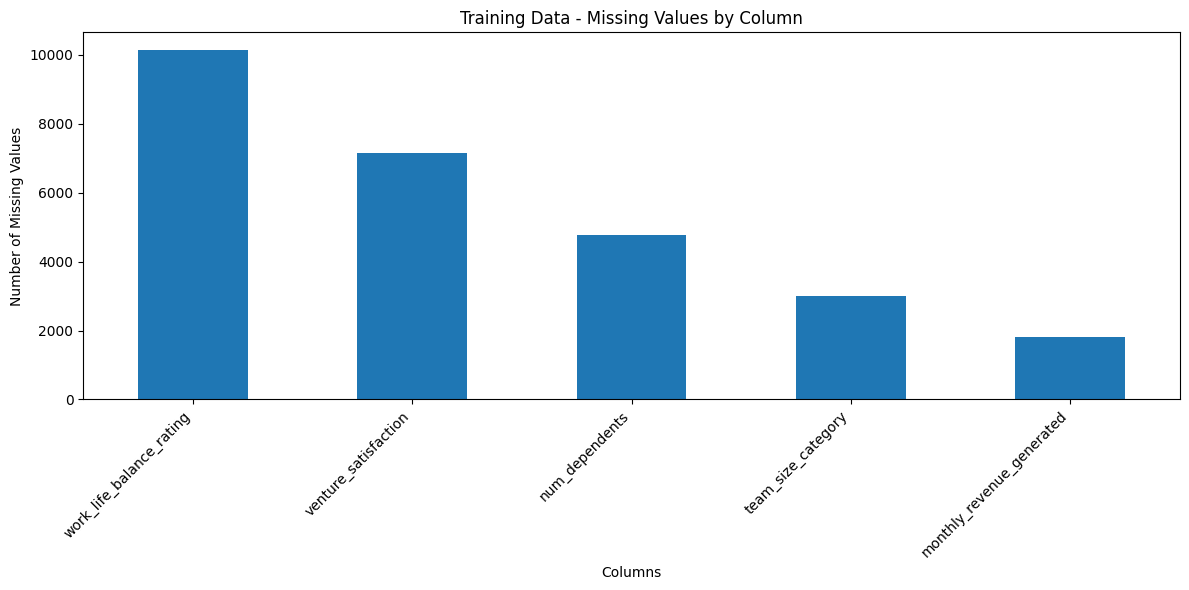

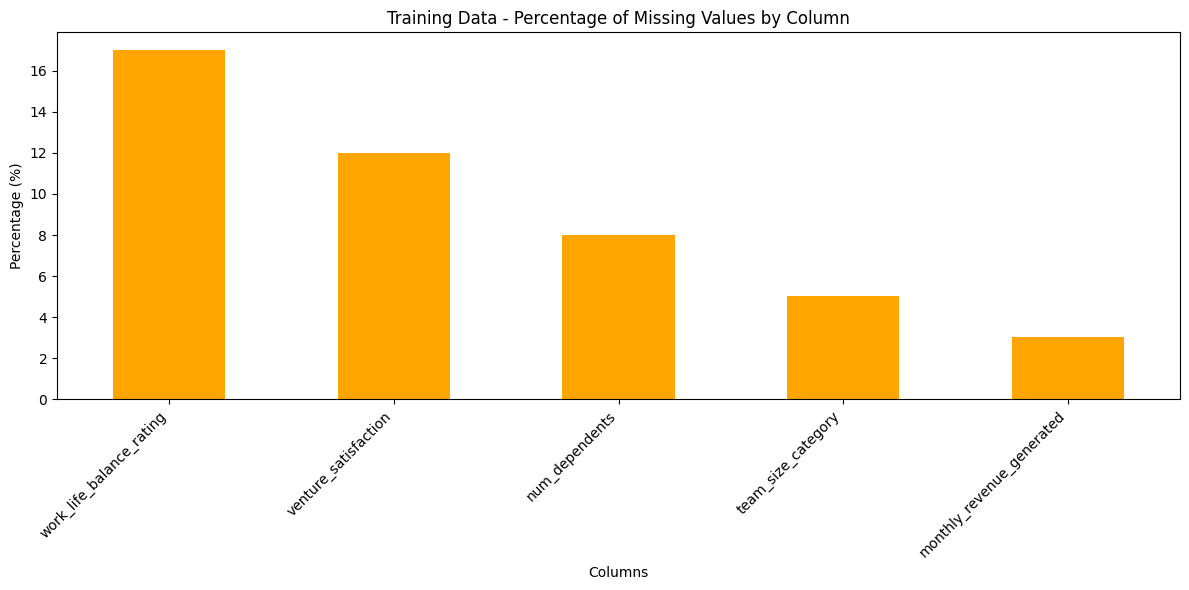

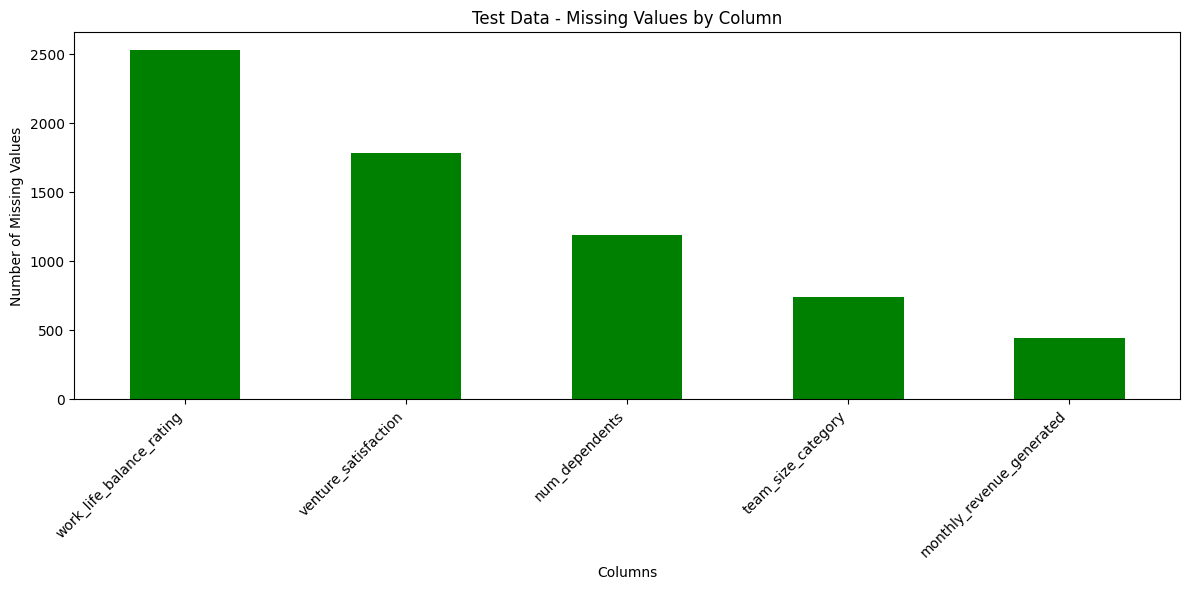

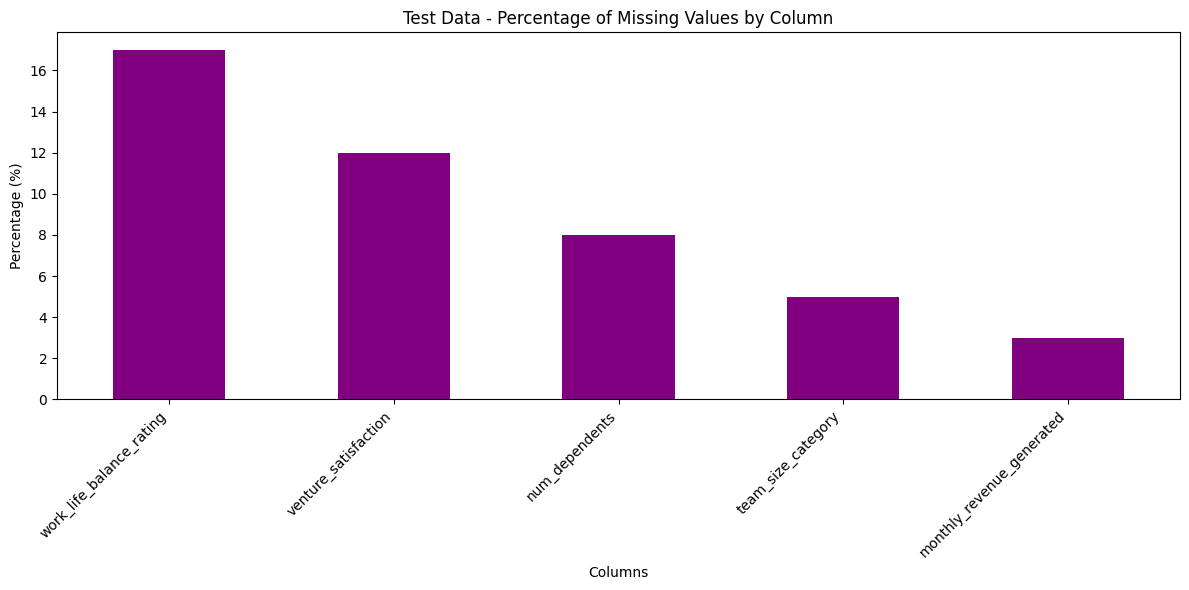

In [5]:
# Visualize missing values
print("\n" + "="*70)
print("VISUALIZING MISSING VALUES")
print("="*70)

# Training data visualization
if len(train_missing_summary) > 0:
    plt.figure(figsize=(12, 6))
    train_missing_summary.plot(kind='bar')
    plt.title('Training Data - Missing Values by Column')
    plt.xlabel('Columns')
    plt.ylabel('Number of Missing Values')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    plt.figure(figsize=(12, 6))
    (train_missing_summary / len(train_df) * 100).plot(kind='bar', color='orange')
    plt.title('Training Data - Percentage of Missing Values by Column')
    plt.xlabel('Columns')
    plt.ylabel('Percentage (%)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Test data visualization
if len(test_missing_summary) > 0:
    plt.figure(figsize=(12, 6))
    test_missing_summary.plot(kind='bar', color='green')
    plt.title('Test Data - Missing Values by Column')
    plt.xlabel('Columns')
    plt.ylabel('Number of Missing Values')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    plt.figure(figsize=(12, 6))
    (test_missing_summary / len(test_df) * 100).plot(kind='bar', color='purple')
    plt.title('Test Data - Percentage of Missing Values by Column')
    plt.xlabel('Columns')
    plt.ylabel('Percentage (%)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


## Step 4: Handle Missing Values Appropriately

**Important**: We calculate imputation statistics from **TRAINING data only**, then apply the same values to both training and test datasets. This ensures:
- **Consistency** between train and test preprocessing
- **No data leakage** from test into training statistics
- **Realistic inference** scenario (matching production deployment)

**Imputation Strategy**:
- **Numerical columns**: Fill with median calculated from training data
- **Categorical columns**: Fill with mode (most frequent value) calculated from training data
- Both datasets use the same imputation values from training statistics


In [6]:
# Identify column types for both datasets
print("="*70)
print("STEP 4: HANDLING MISSING VALUES")
print("="*70)

# Training data column types
train_numerical_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
train_categorical_cols = train_df.select_dtypes(include=['object']).columns.tolist()

# Test data column types
test_numerical_cols = test_df.select_dtypes(include=[np.number]).columns.tolist()
test_categorical_cols = test_df.select_dtypes(include=['object']).columns.tolist()

print(f"\nTraining data:")
print(f"  Numerical columns: {train_numerical_cols}")
print(f"  Categorical columns: {train_categorical_cols}")

print(f"\nTest data:")
print(f"  Numerical columns: {test_numerical_cols}")
print(f"  Categorical columns: {test_categorical_cols}")

# Check which columns have missing values
train_missing_numerical = [col for col in train_numerical_cols if train_df[col].isnull().sum() > 0]
train_missing_categorical = [col for col in train_categorical_cols if train_df[col].isnull().sum() > 0]

test_missing_numerical = [col for col in test_numerical_cols if test_df[col].isnull().sum() > 0]
test_missing_categorical = [col for col in test_categorical_cols if test_df[col].isnull().sum() > 0]

print(f"\nTraining data - columns with missing values:")
print(f"  Numerical: {train_missing_numerical}")
print(f"  Categorical: {train_missing_categorical}")

print(f"\nTest data - columns with missing values:")
print(f"  Numerical: {test_missing_numerical}")
print(f"  Categorical: {test_missing_categorical}")


STEP 4: HANDLING MISSING VALUES

Training data:
  Numerical columns: ['founder_id', 'founder_age', 'years_with_startup', 'monthly_revenue_generated', 'funding_rounds_led', 'distance_from_investor_hub', 'num_dependents']
  Categorical columns: ['founder_gender', 'founder_role', 'work_life_balance_rating', 'venture_satisfaction', 'startup_performance_rating', 'working_overtime', 'education_background', 'personal_status', 'startup_stage', 'team_size_category', 'remote_operations', 'leadership_scope', 'innovation_support', 'startup_reputation', 'founder_visibility', 'retention_status']

Test data:
  Numerical columns: ['founder_id', 'founder_age', 'years_with_startup', 'monthly_revenue_generated', 'funding_rounds_led', 'distance_from_investor_hub', 'num_dependents']
  Categorical columns: ['founder_gender', 'founder_role', 'work_life_balance_rating', 'venture_satisfaction', 'startup_performance_rating', 'working_overtime', 'education_background', 'personal_status', 'startup_stage', 'team_s

In [7]:
# Before imputation - check distributions and statistics
print("\n" + "="*70)
print("BEFORE IMPUTATION - STATISTICS")
print("="*70)

print("\nTraining data - Statistics for numerical columns with missing values:")
for col in train_missing_numerical:
    print(f"\n{col}:")
    print(f"  Missing: {train_df[col].isnull().sum()}")
    print(f"  Mean: {train_df[col].mean():.2f}")
    print(f"  Median: {train_df[col].median():.2f}")
    print(f"  Std: {train_df[col].std():.2f}")

print("\nTraining data - Mode for categorical columns with missing values:")
for col in train_missing_categorical:
    print(f"\n{col}:")
    print(f"  Missing: {train_df[col].isnull().sum()}")
    mode_value = train_df[col].mode()
    if len(mode_value) > 0:
        print(f"  Mode: {mode_value[0]}")
        print(f"  Mode count: {(train_df[col] == mode_value[0]).sum()}")
    else:
        print(f"  No mode available (all values are NaN)")

print("\nTest data - Statistics for numerical columns with missing values:")
for col in test_missing_numerical:
    print(f"\n{col}:")
    print(f"  Missing: {test_df[col].isnull().sum()}")
    print(f"  Mean: {test_df[col].mean():.2f}")
    print(f"  Median: {test_df[col].median():.2f}")
    print(f"  Std: {test_df[col].std():.2f}")

print("\nTest data - Mode for categorical columns with missing values:")
for col in test_missing_categorical:
    print(f"\n{col}:")
    print(f"  Missing: {test_df[col].isnull().sum()}")
    mode_value = test_df[col].mode()
    if len(mode_value) > 0:
        print(f"  Mode: {mode_value[0]}")
        print(f"  Mode count: {(test_df[col] == mode_value[0]).sum()}")
    else:
        print(f"  No mode available (all values are NaN)")



BEFORE IMPUTATION - STATISTICS

Training data - Statistics for numerical columns with missing values:

monthly_revenue_generated:
  Missing: 1800
  Mean: 7311.14
  Median: 7358.00
  Std: 2197.39

num_dependents:
  Missing: 4780
  Mean: 1.65
  Median: 1.00
  Std: 1.56

Training data - Mode for categorical columns with missing values:

work_life_balance_rating:
  Missing: 10143
  Mode: Good
  Mode count: 18753

venture_satisfaction:
  Missing: 7164
  Mode: High
  Mode count: 26252

team_size_category:
  Missing: 2992
  Mode: Medium
  Mode count: 28257

Test data - Statistics for numerical columns with missing values:

monthly_revenue_generated:
  Missing: 447
  Mean: 7284.07
  Median: 7323.00
  Std: 2156.85

num_dependents:
  Missing: 1192
  Mean: 1.66
  Median: 1.00
  Std: 1.54

Test data - Mode for categorical columns with missing values:

work_life_balance_rating:
  Missing: 2533
  Mode: Good
  Mode count: 4665

venture_satisfaction:
  Missing: 1788
  Mode: High
  Mode count: 6547

t

In [8]:
# Create copies before imputation for comparison
train_df_before_imputation = train_df.copy()
test_df_before_imputation = test_df.copy()

# IMPORTANT: Calculate imputation values from TRAINING data only
# Then apply to both train and test to ensure consistency
print("\n" + "="*70)
print("STEP 4: HANDLING MISSING VALUES")
print("="*70)
print("NOTE: Using training data statistics for imputation in both datasets")
print("="*70)

# Get all columns that have missing values (union of train and test)
all_missing_numerical = set(train_missing_numerical + test_missing_numerical)
all_missing_categorical = set(train_missing_categorical + test_missing_categorical)

# Calculate imputation values from TRAINING data only
imputation_values = {}

print("\nCalculating imputation values from TRAINING data:")
print("-"*70)

# Calculate medians from training data
for col in all_missing_numerical:
    if col in train_df.columns:
        median_value = train_df[col].median()
        imputation_values[col] = median_value
        print(f"  {col} (numerical): median = {median_value:.2f}")

# Calculate modes from training data
for col in all_missing_categorical:
    if col in train_df.columns:
        mode_values = train_df[col].mode()
        if len(mode_values) > 0:
            mode_value = mode_values[0]
            imputation_values[col] = mode_value
            print(f"  {col} (categorical): mode = '{mode_value}'")
        else:
            imputation_values[col] = 'Unknown'
            print(f"  {col} (categorical): mode = 'Unknown' (no mode available)")

# Apply imputation to TRAINING data
print("\n" + "="*70)
print("IMPUTING TRAINING DATA")
print("="*70)

print("\nImputing Numerical Columns with Training Median:")
for col in train_missing_numerical:
    if col in imputation_values:
        impute_value = imputation_values[col]
        missing_count = train_df[col].isnull().sum()
        train_df[col].fillna(impute_value, inplace=True)
        print(f"  {col}: Filled {missing_count} missing values with median = {impute_value:.2f}")

print("\nImputing Categorical Columns with Training Mode:")
for col in train_missing_categorical:
    if col in imputation_values:
        impute_value = imputation_values[col]
        missing_count = train_df[col].isnull().sum()
        train_df[col].fillna(impute_value, inplace=True)
        print(f"  {col}: Filled {missing_count} missing values with mode = '{impute_value}'")

# Apply imputation to TEST data using SAME values from training
print("\n" + "="*70)
print("IMPUTING TEST DATA (using training statistics)")
print("="*70)

print("\nImputing Numerical Columns with Training Median:")
for col in test_missing_numerical:
    if col in imputation_values:
        impute_value = imputation_values[col]
        missing_count = test_df[col].isnull().sum()
        test_df[col].fillna(impute_value, inplace=True)
        print(f"  {col}: Filled {missing_count} missing values with training median = {impute_value:.2f}")
    else:
        # Fallback: calculate from test if column doesn't exist in train
        median_value = test_df[col].median()
        missing_count = test_df[col].isnull().sum()
        test_df[col].fillna(median_value, inplace=True)
        print(f"  {col}: Filled {missing_count} missing values with test median = {median_value:.2f} (not in training)")

print("\nImputing Categorical Columns with Training Mode:")
for col in test_missing_categorical:
    if col in imputation_values:
        impute_value = imputation_values[col]
        missing_count = test_df[col].isnull().sum()
        test_df[col].fillna(impute_value, inplace=True)
        print(f"  {col}: Filled {missing_count} missing values with training mode = '{impute_value}'")
    else:
        # Fallback: calculate from test if column doesn't exist in train
        mode_values = test_df[col].mode()
        if len(mode_values) > 0:
            mode_value = mode_values[0]
            missing_count = test_df[col].isnull().sum()
            test_df[col].fillna(mode_value, inplace=True)
            print(f"  {col}: Filled {missing_count} missing values with test mode = '{mode_value}' (not in training)")
        else:
            missing_count = test_df[col].isnull().sum()
            test_df[col].fillna('Unknown', inplace=True)
            print(f"  {col}: Filled {missing_count} missing values with 'Unknown' (not in training, no mode)")

print("\n" + "="*70)
print("IMPUTATION COMPLETE!")
print("="*70)
print("✓ Both datasets imputed using training data statistics for consistency")
print("="*70)



STEP 4: HANDLING MISSING VALUES
NOTE: Using training data statistics for imputation in both datasets

Calculating imputation values from TRAINING data:
----------------------------------------------------------------------
  num_dependents (numerical): median = 1.00
  monthly_revenue_generated (numerical): median = 7358.00
  venture_satisfaction (categorical): mode = 'High'
  team_size_category (categorical): mode = 'Medium'
  work_life_balance_rating (categorical): mode = 'Good'

IMPUTING TRAINING DATA

Imputing Numerical Columns with Training Median:
  monthly_revenue_generated: Filled 1800 missing values with median = 7358.00
  num_dependents: Filled 4780 missing values with median = 1.00

Imputing Categorical Columns with Training Mode:
  work_life_balance_rating: Filled 10143 missing values with mode = 'Good'
  venture_satisfaction: Filled 7164 missing values with mode = 'High'
  team_size_category: Filled 2992 missing values with mode = 'Medium'

IMPUTING TEST DATA (using traini

/var/folders/w1/h8z88ggs70x5m3kjwhnx8g2r0000gn/T/ipykernel_27836/348452591.py:52: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df[col].fillna(impute_value, inplace=True)
/var/folders/w1/h8z88ggs70x5m3kjwhnx8g2r0000gn/T/ipykernel_27836/348452591.py:60: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alwa

In [9]:
# Verify no missing values remain in both datasets
print("\n" + "="*70)
print("VERIFYING NO MISSING VALUES REMAIN")
print("="*70)

train_remaining_missing = train_df.isnull().sum().sum()
test_remaining_missing = test_df.isnull().sum().sum()

print("\nTraining data:")
if train_remaining_missing == 0:
    print("✓ SUCCESS: No missing values remaining in training data!")
else:
    print(f"⚠ WARNING: Still have {train_remaining_missing} missing values in training data")
    print(train_df.isnull().sum()[train_df.isnull().sum() > 0])

print("\nTest data:")
if test_remaining_missing == 0:
    print("✓ SUCCESS: No missing values remaining in test data!")
else:
    print(f"⚠ WARNING: Still have {test_remaining_missing} missing values in test data")
    print(test_df.isnull().sum()[test_df.isnull().sum() > 0])

print(f"\nFinal training dataset shape: {train_df.shape}")
print(f"Final test dataset shape: {test_df.shape}")
print(f"\nTraining columns: {len(train_df.columns)}")
print(f"Test columns: {len(test_df.columns)}")



VERIFYING NO MISSING VALUES REMAIN

Training data:
✓ SUCCESS: No missing values remaining in training data!

Test data:
✓ SUCCESS: No missing values remaining in test data!

Final training dataset shape: (59608, 23)
Final test dataset shape: (14900, 22)

Training columns: 23
Test columns: 22


## Step 5: Save the Cleaned Dataset


In [10]:
# Save the cleaned datasets
print("="*70)
print("STEP 5: SAVING CLEANED DATASETS")
print("="*70)

# Save training dataset
train_output_path = 'dataset/train_dropped_column.csv'
train_df.to_csv(train_output_path, index=False)
print(f"\n✓ Training dataset saved to: {train_output_path}")
print(f"  Rows: {len(train_df)}, Columns: {len(train_df.columns)}")

# Save test dataset
test_output_path = 'dataset/test_dropped_column.csv'
test_df.to_csv(test_output_path, index=False)
print(f"\n✓ Test dataset saved to: {test_output_path}")
print(f"  Rows: {len(test_df)}, Columns: {len(test_df.columns)}")

# Summary statistics
print("\n" + "="*70)
print("SUMMARY OF CHANGES")
print("="*70)

print("\nTRAINING DATASET:")
print(f"1. Removed {num_rows_removed} rows with inconsistent age data (years_with_startup > founder_age)")
print(f"2. Dropped column: years_since_founding")
print(f"3. Handled missing values:")
print(f"   - Numerical columns: Filled with median")
print(f"   - Categorical columns: Filled with mode")
print(f"\n   Original: {train_original_row_count} rows, {train_original_col_count} columns")
print(f"   Final: {len(train_df)} rows, {len(train_df.columns)} columns")
print(f"   Rows removed: {train_original_row_count - len(train_df)}")
print(f"   Columns removed: {train_original_col_count - len(train_df.columns)}")

print("\nTEST DATASET:")
print(f"1. NO rows removed (kept all rows as requested)")
print(f"2. Dropped column: years_since_founding")
print(f"3. Handled missing values:")
print(f"   - Numerical columns: Filled with median")
print(f"   - Categorical columns: Filled with mode")
print(f"\n   Original: {test_original_row_count} rows, {test_original_col_count} columns")
print(f"   Final: {len(test_df)} rows, {len(test_df.columns)} columns")
print(f"   Rows removed: {test_original_row_count - len(test_df)} (none)")
print(f"   Columns removed: {test_original_col_count - len(test_df.columns)}")

print("\n" + "="*70)
print("OUTPUT FILES:")
print("="*70)
print(f"  - {train_output_path}")
print(f"  - {test_output_path}")
print("="*70)


STEP 5: SAVING CLEANED DATASETS

✓ Training dataset saved to: dataset/train_dropped_column.csv
  Rows: 59608, Columns: 23

✓ Test dataset saved to: dataset/test_dropped_column.csv
  Rows: 14900, Columns: 22

SUMMARY OF CHANGES

TRAINING DATASET:
1. Removed 3 rows with inconsistent age data (years_with_startup > founder_age)
2. Dropped column: years_since_founding
3. Handled missing values:
   - Numerical columns: Filled with median
   - Categorical columns: Filled with mode

   Original: 59611 rows, 24 columns
   Final: 59608 rows, 23 columns
   Rows removed: 3
   Columns removed: 1

TEST DATASET:
1. NO rows removed (kept all rows as requested)
2. Dropped column: years_since_founding
3. Handled missing values:
   - Numerical columns: Filled with median
   - Categorical columns: Filled with mode

   Original: 14900 rows, 23 columns
   Final: 14900 rows, 22 columns
   Rows removed: 0 (none)
   Columns removed: 1

OUTPUT FILES:
  - dataset/train_dropped_column.csv
  - dataset/test_dropped